In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    'grid.linestyle':    '--',
    'grid.linewidth':    0.4,
    'axes.linewidth':   0.8,
})

def bootstrap_ci_width(x, n_resamples=10):
    """Return upper 95% bootstrap CI distance from the mean."""
    result = stats.bootstrap(
        (x.dropna().values,),
        np.mean,
        confidence_level=0.95,
        n_resamples=n_resamples,
        random_state=1,
        method="percentile",
    )
    mean = np.mean(x)
    return result.confidence_interval.high - mean


def clean_axis(ax, xlabel="", ylabel=""):
    """Apply minimal Nature-style axis formatting."""
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(direction="out", length=4, width=1.1)

# Load data

In [4]:
df1 = pd.read_parquet("data_first_au.parquet")
df2 = pd.read_parquet("data_last_au.parquet")

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

gender_map = {1.0: "Female", 0.0: "Male"}

colors = {
    "Female": "#CC79A7",
    "Male": "#0072B2"
}

markers = {
    "Female": "o",
    "Male": "s"
}


def make_gender_df(d, gender_col):
    d = d[d[gender_col].isin([0.0, 1.0])].copy()
    d["Gender"] = d[gender_col].map(gender_map)
    return d

def bootstrap_ci(x, n_resamples=10):
    x = pd.Series(x).dropna().values

    if len(x) < 2:
        m = np.mean(x)
        return m, m

    res = stats.bootstrap(
        (x,),
        np.mean,
        confidence_level=0.95,
        n_resamples=n_resamples,
        random_state=1,
        method="percentile"
    )

    return res.confidence_interval.low, res.confidence_interval.high

def summary_by_gender(d, outcome):
    rows = []

    for gender, g in d.groupby("Gender"):
        mean = g[outcome].mean()
        low, high = bootstrap_ci(g[outcome])

        rows.append({
            "Gender": gender,
            "mean": mean,
            "low": low,
            "high": high,
            "n": len(g)
        })

    return pd.DataFrame(rows)

def summary_by_year_gender(d, outcome):
    rows = []

    for (year, gender), g in d.groupby(["Year", "Gender"]):
        mean = g[outcome].mean()
        low, high = bootstrap_ci(g[outcome])

        rows.append({
            "Year": year,
            "Gender": gender,
            "mean": mean,
            "low": low,
            "high": high,
            "n": len(g)
        })

    return pd.DataFrame(rows)

def gap_by_year(d, outcome):
    s = summary_by_year_gender(d, outcome)

    wide_mean = (
        s.pivot(index="Year", columns="Gender", values="mean")
         .reset_index()
    )

    wide_low = (
        s.pivot(index="Year", columns="Gender", values="low")
         .reset_index()
    )

    wide_high = (
        s.pivot(index="Year", columns="Gender", values="high")
         .reset_index()
    )

    gap = wide_mean[["Year"]].copy()
    gap["gap"] = wide_mean["Female"] - wide_mean["Male"]

    # Conservative CI approximation using separate CIs
    gap["low"] = wide_low["Female"] - wide_high["Male"]
    gap["high"] = wide_high["Female"] - wide_low["Male"]

    return gap.dropna()

def clean_axis(ax, xlabel="", ylabel=""):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def draw_inset_bar(ax, d, outcome):

    inset = inset_axes(
        ax,
        width="24%",
        height="30%",
        loc="upper left",
        borderpad=1.0
    )

    s = summary_by_gender(d, outcome)

    s["Gender"] = pd.Categorical(
        s["Gender"],
        categories=["Female", "Male"],
        ordered=True
    )

    s = s.sort_values("Gender")

    yerr = np.vstack([
        s["mean"] - s["low"],
        s["high"] - s["mean"]
    ])

    inset.bar(
        s["Gender"],
        s["mean"],
        yerr=yerr,
        capsize=2,
        width=0.55,
        color=[colors[g] for g in s["Gender"]],
        edgecolor="black"
    )

    # --------------------
    # Share y-scale
    # --------------------

    ymin, ymax = ax.get_ylim()

    inset.set_ylim(ymin, ymax)

    # --------------------
    # Style
    # --------------------

    inset.set_title(
        "Overall",
        pad=2
    )

    inset.tick_params(
        axis="x"
    )

    inset.set_yticks([])

    inset.spines["top"].set_visible(False)
    inset.spines["right"].set_visible(False)

    inset.grid(
        axis="y",
        alpha=0.2
    )

    inset.set_xlabel("")
    inset.set_ylabel("")

def draw_line_with_inset(ax, d, outcome, title, ylabel):
    s = summary_by_year_gender(d, outcome)

    for gender in ["Female", "Male"]:
        sub = s[s["Gender"] == gender].sort_values("Year")

        if sub.empty:
            continue

        ax.plot(
            sub["Year"],
            sub["mean"],
            color=colors[gender],
            marker=markers[gender],
            markersize=3,
            label=gender
        )

        ax.fill_between(
            sub["Year"],
            sub["low"],
            sub["high"],
            color=colors[gender],
            alpha=0.16,
            linewidth=0
        )

    clean_axis(ax, xlabel="Year", ylabel=ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.35)

    if not s.empty:
        ax.set_ylim(
            0,
            min(
                1,
                s["high"].max() + 0.005
            )
        )

    draw_inset_bar(
        ax,
        d,
        outcome
    )

    draw_inset_bar(ax, d, outcome)

def draw_gap(ax, d, outcome, title, ylabel="Female − Male"):
    gap = gap_by_year(d, outcome)

    ax.axhline(
        0,
        color="black",
        linestyle="--"
    )

    ax.plot(
        gap["Year"],
        gap["gap"],
        color="black",
        marker="o",
        markersize=3
    )

    ax.fill_between(
        gap["Year"],
        gap["low"],
        gap["high"],
        color="black",
        alpha=0.14,
        linewidth=0
    )

    clean_axis(ax, xlabel="Year", ylabel=ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.35)

    ymax = np.nanmax(np.abs([gap["low"].min(), gap["high"].max()]))
    ax.set_ylim(-ymax * 1.1, ymax * 1.1)

In [4]:
first_df = make_gender_df(df1, gender_col="first_Female")
last_df = make_gender_df(df2, gender_col="last_Female")

first_df = first_df[first_df["Year"] <= 2024].copy()
last_df = last_df[last_df["Year"] <= 2024].copy()

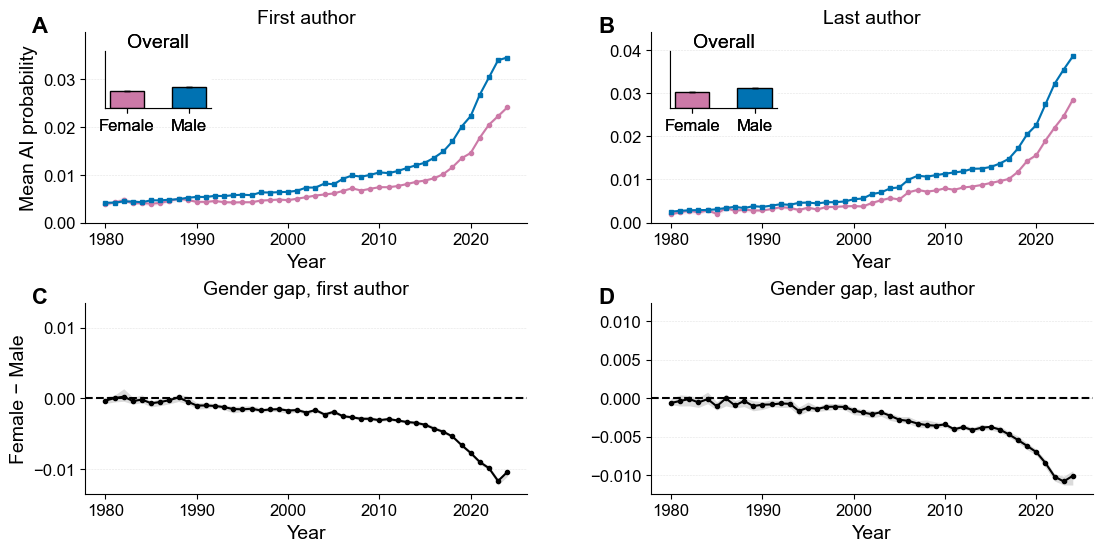

In [ ]:
fig = plt.figure(figsize=(13, 6))

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.28,
    hspace=0.42
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

draw_line_with_inset(
    ax1,
    first_df,
    outcome="AIProb",
    title="First author",
    ylabel="Mean AI probability"
)

draw_line_with_inset(
    ax2,
    last_df,
    outcome="AIProb",
    title="Last author",
    ylabel=""
)

draw_gap(
    ax3,
    first_df,
    outcome="AIProb",
    title="Gender gap, first author"
)

draw_gap(
    ax4,
    last_df,
    outcome="AIProb",
    title="Gender gap, last author",
    ylabel=""
)


# One shared legend
# handles, labels = ax1.get_legend_handles_labels()
# fig.legend(
#     handles,
#     labels,
#     frameon=False,
#     loc="upper center",
#     ncol=2,
#     bbox_to_anchor=(0.5, 1.02)
# )

for ax, label in zip(
    [ax1, ax2, ax3, ax4],
    ["A", "B", "C", "D"]
):
    ax.text(
        -0.12,
        1.08,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top"
    )

plt.savefig("Data/fig1_year.pdf", bbox_inches="tight")